In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

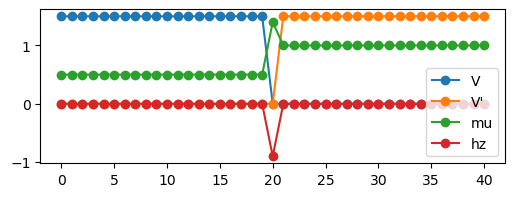

In [2]:
widthD = 20
widthF = 1
widthP = 20

X, Y = widthD+widthF+widthP, 200
lattice = Lattice(X, Y)

t = 1
T = 0.2

muD = 0.5 * t
muP = 1.0 * t
muF = 1.4 * t
mu = np.zeros(lattice.X)
mu[:widthD] = muD
mu[widthD:widthD + widthF] = muF
mu[widthD + widthF:] = muP

hz0 = -0.9 * t
hz = np.zeros_like(mu)
hz[widthD:widthD + widthF] = hz0


V_prime0 = 1.5 * t
V_prime = V_prime0 * np.ones(lattice.X)
V_prime[:widthF+widthD] = 0 

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)
V[widthD:] = 0 

plt.figure(figsize=(6,2))
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(hz, '-o', label='hz') 
plt.legend()

In [3]:
H = Hamiltonian(t, mu, lattice, U=None, V_prime=V_prime, V=V,
                F_init=[0.1, 0.1, -0.1, -0.1],
                Fuu_init=[0.1, -0.1, 0.1j, -0.1j],
                Fdd_init=[0.1, -0.1, 0.1j, -0.1j],
                hy=hz, F0_init=0.1)

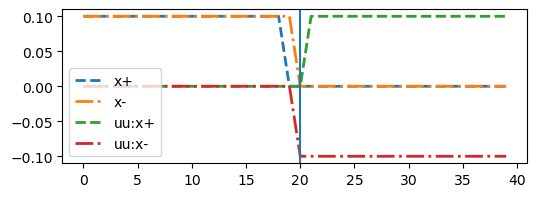

In [4]:
plt.figure(figsize=(6,2))
if V is not None:
    plt.plot(np.real(H.F_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.F_xmin), label="x-", linestyle='-.', lw=2)
if V_prime is not None:
    plt.plot(np.real(H.Fuu_xplus), label="uu:x+", linestyle='--', lw=2)
    plt.plot(np.real(H.Fuu_xmin), label="uu:x-", linestyle='-.', lw=2)
plt.legend()
plt.axvline(widthD)

In [5]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-4, rtol=0.01, maxiter=500, verbose=False, temperature=T)

In [6]:
F, Fuu, Fdd = H.get_correlations()

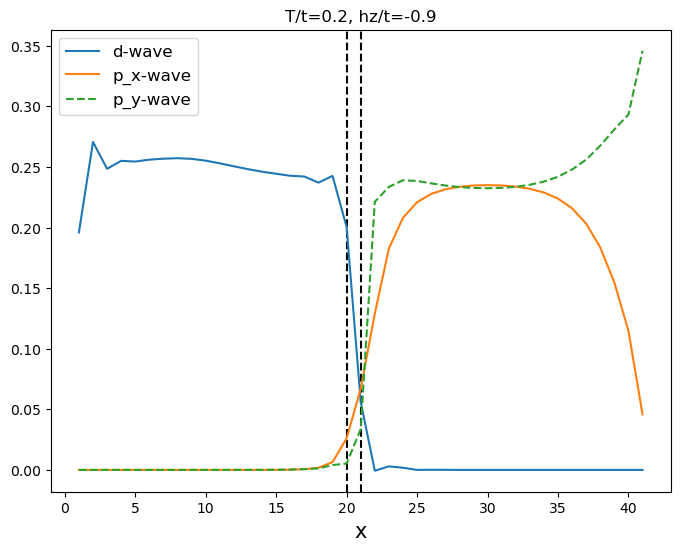

In [12]:
x = np.arange(1, widthD + widthF + widthP + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}, hz/t={hz0}")

# axs.axhline(0, color = 'black')
# axs.axhline(0.2, color = 'black')

axs.axvline(widthD, color='black', linestyle='--')
axs.axvline(widthD+widthF, color='black', linestyle='--')
axs.plot(x, np.real(F_dwave), label="d-wave")
# axs.plot(x, np.abs(F_swave), "--", label="s-wave")
axs.plot(x, np.abs(Fuu.px), label="p_x-wave")
axs.plot(x, np.abs(Fuu.py), "--", label="p_y-wave")
# axs.plot(x, np.imag(Fuu.px), label="p_x-wave")
# axs.plot(x, np.real(Fuu.py), "--", label="p_y-wave")
axs.set_xlabel("x", fontsize=15)
axs.legend(fontsize=12, loc="best")
plt.savefig('../figures/SFP.pdf')
plt.show()

### TODO: CHECK Tc